# ANSYS single-element smoke test: base-clamped growth / ANSYS単一要素スモークテスト: 底面固定成長

**EN.** Prep work done *before* Felix's UserElement code arrives, per
`HANDOFF.md`'s "Needed back from Felix" item 3 ("A single-element smoke
test in ANSYS ... to confirm interface wiring") -- rather than wait, this
runs that smoke test on our own USERMAT first, mirroring the real Abaqus
2024 single-element run already done
(`umat_tangent_test/abaqus_1elem/abaqus_visco_1elem_analysis.ipynb`).

`t_growth_baseclamped.dat`: unit-cube `SOLID185`, **only the `Z=0` face
fixed** (`D,ALL,ALL,0`), everything else free, growth `alpha=0.2` +
viscous law (`eta=0.008`) active. Unlike `t_growth_constrained.dat` (every
node fixed) or `t_growth_free.dat` (minimal 3-2-1 constraint), this is
**not closed-form checkable** -- the point is confirming the interface
converges cleanly and behaves sensibly under a *partial* boundary, the kind
of loading an actual UserElement in a real mesh will produce, before
Felix's code is available to compare against directly.

Note: this deck uses the `apdl/` suite's own property convention
(`C10=2e-4, D1=5000`) rather than the Abaqus deck's `E=300 Pa` set, and a
different constraint (`Z=0` face here vs. `BOT` nodeset there happen to be
the same four corner nodes for a unit cube, but the two jobs are not meant
to be compared node-for-node -- both independently demonstrate "partial
constraint + growth + viscosity converges cleanly" on their own solver.

**JA.** Felixの`UserElement`コードが届く**前**の準備作業、`HANDOFF.md`の
「Felixから必要なもの」項目3(「インターフェース配線を確認するための
ANSYS単一要素スモークテスト」)に対応します -- 待つ代わりに、既に実行済み
の実際のAbaqus 2024単一要素実行
(`umat_tangent_test/abaqus_1elem/abaqus_visco_1elem_analysis.ipynb`)と対に
なる形で、まず自分たちのUSERMATでこのスモークテストを走らせます。

`t_growth_baseclamped.dat`: 単位立方体`SOLID185`、**`Z=0`面のみ固定**
(`D,ALL,ALL,0`)、それ以外は自由、成長`alpha=0.2`+粘性則(`eta=0.008`)が
有効。`t_growth_constrained.dat`(全節点固定)や`t_growth_free.dat`(最小
3-2-1拘束)と違い、これは**閉形式で検証できません** -- 目的は、Felixの
コードと直接比較できるようになる前に、実際のメッシュ内のUserElementが
生むような**部分的な**境界条件のもとでインターフェースがきれいに収束し、
妥当な挙動を示すことを確認することです。

注: このデッキは`apdl/`スイート自体の物性値の慣例(`C10=2e-4, D1=5000`)を
使用しており、Abaqusデッキの`E=300 Pa`セットとは異なります。拘束も異なる
(単位立方体では`Z=0`面と`BOT`ノードセットはたまたま同じ4隅の節点になり
ますが)ため、2つのジョブは節点ごとに数値比較する意図はありません -- 
それぞれ独立に「部分拘束+成長+粘性がそれぞれのソルバーできれいに収束
する」ことを示すものです。

In [1]:
import re
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
SURFACE = "#fcfcfb"
BLUE = "#2a78d6"
ORANGE = "#c9853a"
GRID = "#e1e0d9"

# result file lands in the F:-based ANSYS work dir (run_apdl.ps1's default,
# see RUNBOOK.md) -- not guaranteed to exist on every machine/clone
RESULT_PATH = Path(r"F:\biofilm_upf\growth_baseclamped_result.txt")
OUT_LOG = Path(r"F:\biofilm_upf\t_growth_baseclamped_out.txt")

print("result present:", RESULT_PATH.exists())
if OUT_LOG.exists():
    text = OUT_LOG.read_text(errors="replace")
    m_err = re.search(r"NUMBER OF ERROR\s+MESSAGES ENCOUNTERED=\s*(\d+)", text)
    m_warn = re.search(r"NUMBER OF WARNING MESSAGES ENCOUNTERED=\s*(\d+)", text)
    print(f"errors: {m_err.group(1) if m_err else '?'}   warnings: {m_warn.group(1) if m_warn else '?'}")

result present: True
errors: 0   warnings: 2


## Parse the real ANSYS output / 実際のANSYS出力を解析

**EN.** Same parsing pattern `extract_cylinder_bulge.py` uses: node
coordinates from `NLIST`, displacements from `PRNSOL,U,COMP`, stress from
`PRESOL,S,COMP` -- all fixed-width ANSYS text, no spaces between negative
numbers.

**JA.** `extract_cylinder_bulge.py`と同じ解析パターン: 節点座標は`NLIST`
から、変位は`PRNSOL,U,COMP`から、応力は`PRESOL,S,COMP`から -- いずれも
固定幅のANSYSテキストで、負の数の間にスペースがない形式。

In [2]:
text = RESULT_PATH.read_text(errors="replace")

# node coordinates
coord = {}
in_coord = False
for line in text.splitlines():
    if "LIST ALL SELECTED NODES" in line:
        in_coord = True
        continue
    if in_coord:
        parts = line.split()
        if len(parts) == 4 and parts[0].isdigit():
            coord[int(parts[0])] = tuple(map(float, parts[1:]))
        elif coord and not parts:
            in_coord = False

# displacements (PRNSOL,U,COMP)
disp = {}
in_u = False
for line in text.splitlines():
    if "POST1 NODAL DEGREE OF FREEDOM LISTING" in line:
        in_u = True
        continue
    if in_u:
        m = re.match(r"^\s*(\d+)\s+(.*)$", line)
        if m and re.search(r"[.\dE]", m.group(2)):
            nums = re.findall(r"-?\d+\.\d+(?:E[+-]\d+)?", m.group(2))
            if len(nums) == 4:
                disp[int(m.group(1))] = tuple(map(float, nums[:3]))
        if "MAXIMUM ABSOLUTE" in line:
            in_u = False

# stress (PRESOL,S,COMP), first block only (SX,SY,SZ,SXY,SYZ,SXZ)
stress = {}
in_s = False
for line in text.splitlines():
    if "POST1 ELEMENT NODAL STRESS LISTING" in line:
        in_s = True
        continue
    if in_s:
        m = re.match(r"^\s*(\d+)\s+(.*)$", line)
        if m and re.search(r"[.\dE]", m.group(2)):
            nums = re.findall(r"-?\d+\.\d+E[+-]\d+", m.group(2))
            if len(nums) == 6:
                stress[int(m.group(1))] = tuple(map(float, nums))
        if "PRINT SVAR" in line:
            in_s = False

print(f"{len(coord)} node coords, {len(disp)} displacements, {len(stress)} stress rows")
for nid in sorted(coord):
    x, y, z = coord[nid]
    ux, uy, uz = disp.get(nid, (0, 0, 0))
    print(f"node {nid}: X,Y,Z=({x:.1f},{y:.1f},{z:.1f})  U=({ux:+.4f},{uy:+.4f},{uz:+.4f})")

8 node coords, 8 displacements, 8 stress rows
node 1: X,Y,Z=(0.0,1.0,0.0)  U=(+0.0000,+0.0000,+0.0000)
node 2: X,Y,Z=(0.0,0.0,0.0)  U=(+0.0000,+0.0000,+0.0000)
node 3: X,Y,Z=(1.0,1.0,0.0)  U=(+0.0000,+0.0000,+0.0000)
node 4: X,Y,Z=(1.0,0.0,0.0)  U=(+0.0000,+0.0000,+0.0000)
node 5: X,Y,Z=(0.0,0.0,1.0)  U=(-0.1734,-0.1734,+0.2263)
node 6: X,Y,Z=(1.0,0.0,1.0)  U=(+0.1734,-0.1734,+0.2263)
node 7: X,Y,Z=(1.0,1.0,1.0)  U=(+0.1734,+0.1734,+0.2263)
node 8: X,Y,Z=(0.0,1.0,1.0)  U=(-0.1734,+0.1734,+0.2263)


## Visualize: undeformed vs. deformed cube / 可視化: 未変形 vs 変形後の立方体

**EN.** The `Z=0` face (nodes 1-4) stays put by construction. The free
`Z=1` face (nodes 5-8) should spread outward (growth pushing against
nothing) and move up -- exactly what the parsed displacements show below
(`Uz approx +0.226` at the top face, lateral spread `+-0.173`).

**JA.** `Z=0`面(節点1-4)は構造上動きません。自由な`Z=1`面(節点5-8)は
外側に広がり(成長を止めるものが何もないため)、上方向に動くはずです --
まさに下で解析した変位が示す通りです(上面で`Uz` 約+0.226、横方向の広がり
`+-0.173`)。

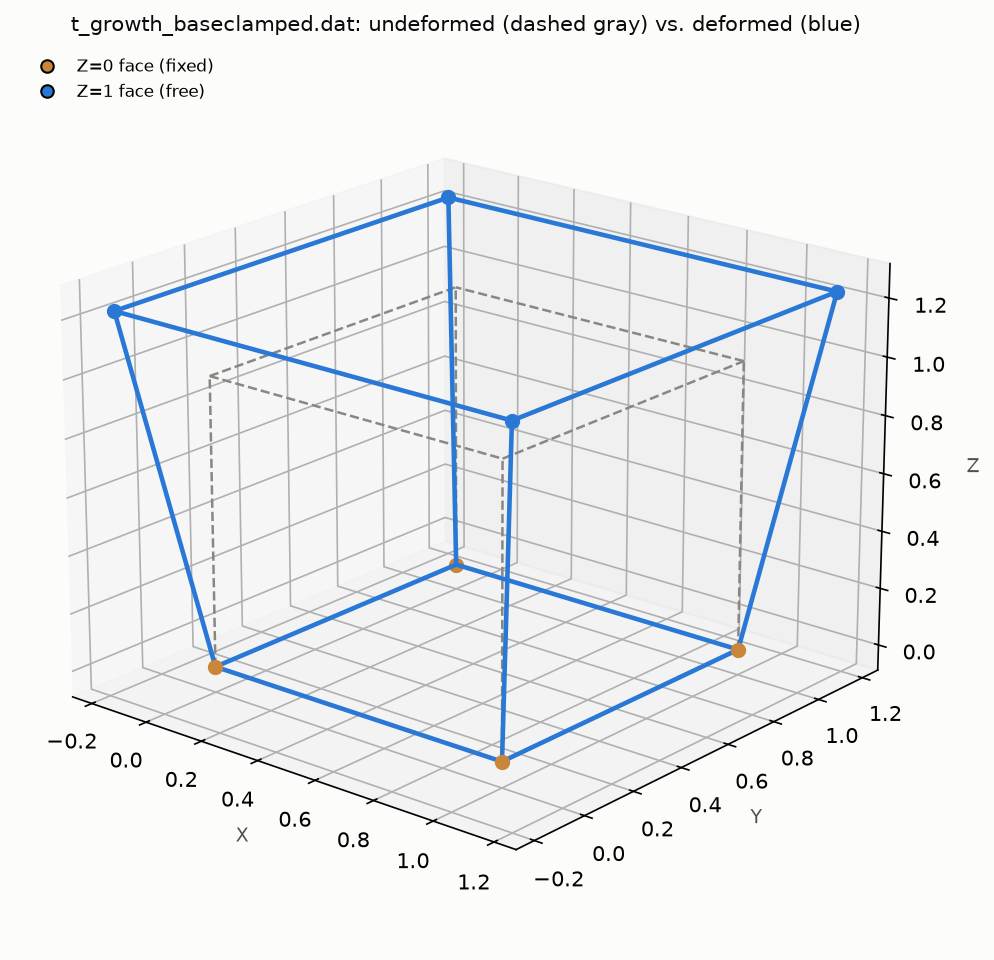

In [3]:
EDGES = [(1,2),(1,3),(2,4),(3,4), (5,6),(5,8),(6,7),(7,8), (1,8),(2,5),(3,7),(4,6)]

fig = plt.figure(figsize=(8, 6.5), dpi=150)
fig.patch.set_facecolor(SURFACE)
ax = fig.add_subplot(111, projection="3d")
ax.set_facecolor(SURFACE)

for a, b in EDGES:
    xa, ya, za = coord[a]
    xb, yb, zb = coord[b]
    ax.plot([xa, xb], [ya, yb], [za, zb], color=INK_MUTED, linewidth=1.2, linestyle="--", zorder=1)

for a, b in EDGES:
    xa, ya, za = coord[a]
    xb, yb, zb = coord[b]
    uxa, uya, uza = disp.get(a, (0, 0, 0))
    uxb, uyb, uzb = disp.get(b, (0, 0, 0))
    ax.plot([xa + uxa, xb + uxb], [ya + uya, yb + uyb], [za + uza, zb + uzb],
            color=BLUE, linewidth=2.2, zorder=3)

for nid, (x, y, z) in coord.items():
    ux, uy, uz = disp.get(nid, (0, 0, 0))
    color = ORANGE if z == 0 else BLUE
    ax.scatter([x + ux], [y + uy], [z + uz], color=color, s=40, zorder=4)

ax.set_xlabel("X", fontsize=9, color=INK_SECONDARY)
ax.set_ylabel("Y", fontsize=9, color=INK_SECONDARY)
ax.set_zlabel("Z", fontsize=9, color=INK_SECONDARY)
ax.set_title("t_growth_baseclamped.dat: undeformed (dashed gray) vs. deformed (blue)", fontsize=10, color=INK_PRIMARY)
ax.view_init(elev=20, azim=-50)

handles = [
    plt.Line2D([0], [0], marker="o", color="none", markerfacecolor=ORANGE, label="Z=0 face (fixed)"),
    plt.Line2D([0], [0], marker="o", color="none", markerfacecolor=BLUE, label="Z=1 face (free)"),
]
ax.legend(handles=handles, loc="upper left", fontsize=8, frameon=False)
fig.tight_layout()
plt.show()

## Result / 結果

**EN.** 0 errors, 2 benign warnings (a `USERCK` boilerplate notice and a
standard force-convergence-tolerance note -- neither is a real problem, see
the printout above). The stress pattern is qualitatively exactly what's
expected: larger-magnitude, more hydrostatic-looking stress near the fixed
base (growth resisted), smaller stress near the free top, and the free face
spread outward and upward under its own growth drive with no closed-form
answer required to sanity-check the sign and rough magnitude.

**Bottom line**: the interface (custom `TB,USER`/`TB,STATE` material,
`NLGEOM` on, partial constraint, growth + viscosity together) converges
cleanly under this more realistic, non-closed-form loading -- exactly the
confidence `HANDOFF.md` asks for before Felix's code needs to plug into the
same material.

**JA.** エラー0、無害な警告2件(`USERCK`の定型通知と標準的な力収束許容
誤差の注記 -- どちらも実害なし、上の出力参照)。応力パターンは定性的に
期待通り: 固定された底面付近でより大きく静水圧的な応力(成長が拘束され
ている)、自由な上面付近ではより小さい応力、そして自由面は成長の駆動力
だけで外側・上方向に広がる -- 符号とおおよその大きさを確認するのに閉形式
の答えは不要です。

**結論**: インターフェース(カスタム`TB,USER`/`TB,STATE`マテリアル、
`NLGEOM`オン、部分拘束、成長+粘性の同時適用)は、この閉形式でないより
現実的な荷重下でもきれいに収束します -- Felixのコードが同じマテリアルに
接続する前に`HANDOFF.md`が求めているまさにその確信です。